In [2]:
# Core imports for the whole lab
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
np.random.seed(28)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.1.3


In [9]:
# 🔹 1A. THE FOUR CONTAINERS

scalar = np.array(10)
vector = np.array([2, 5, 1])
matrix = np.array([[1, 2], [3, 4]])
tensor = np.ones((3, 2, 2))
for name, arr in [('scalar', scalar), ('vector', vector),
                  ('matrix', matrix), ('tensor', tensor)]:
    print(f'{name:7s} ndim={arr.ndim}  shape={arr.shape}')

scalar  ndim=0  shape=()
vector  ndim=1  shape=(3,)
matrix  ndim=2  shape=(2, 2)
tensor  ndim=3  shape=(3, 2, 2)


In [11]:
# 🔹 1B. TENSOR OPERATIONS: add, transpose, reshape

A = np.arange(6).reshape(2, 3)
B = np.ones((2, 3), dtype=int)

print('A:\n', A)
print('A + B (element-wise add):\n', A + B)
print('A.T  (transpose -> shape', A.T.shape, '):\n', A.T)
print('A.reshape(3, 2):\n', A.reshape(3, 2))
print('A.flatten():', A.flatten())

A:
 [[0 1 2]
 [3 4 5]]
A + B (element-wise add):
 [[1 2 3]
 [4 5 6]]
A.T  (transpose -> shape (3, 2) ):
 [[0 3]
 [1 4]
 [2 5]]
A.reshape(3, 2):
 [[0 1]
 [2 3]
 [4 5]]
A.flatten(): [0 1 2 3 4 5]


In [13]:


T = np.arange(12).reshape(3, 4)
print('T:\n', T)
# 1. ndim and shape
print(T.ndim)
print(T.shape)

# 2. T + T
print(T + T)

# 3. Transpose (print .T.shape) and reshape to (2, 6)
print(T.T.shape)
print(T.T.reshape(2, 6))


T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
2
(3, 4)
[[ 0  2  4  6]
 [ 8 10 12 14]
 [16 18 20 22]]
(4, 3)
[[ 0  4  8  1  5  9]
 [ 2  6 10  3  7 11]]


In [15]:
pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])),    # pair 1
    (np.array([1, 2, 3]), np.array([3, 2, 1])),    # pair 2
    (np.array([2, 0, 0]), np.array([0, 5, 0])),    # pair 3
]




for i, (u, v) in enumerate(pairs, start=1):
    # 1. L1 and L2 norm of u
    l1 = np.linalg.norm(u, ord=1)
    l2 = np.linalg.norm(u, ord=2)

    # 2. cosine similarity of u and v
    cosine = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

    print(f"Pair {i}:")
    print("L1 norm:", l1)
    print("L2 norm:", l2)
    print("Cosine similarity:", cosine)
    print()

# 3. Most similar pair = Pair 1


Pair 1:
L1 norm: 2.0
L2 norm: 1.4142135623730951
Cosine similarity: 0.9999999999999998

Pair 2:
L1 norm: 6.0
L2 norm: 3.7416573867739413
Cosine similarity: 0.7142857142857143

Pair 3:
L1 norm: 2.0
L2 norm: 2.0
Cosine similarity: 0.0



In [16]:

M = np.array([[4., 2.],
              [2., 3.]])
P = np.array([[0., -1.],
              [1.,  0.]])   # a 90-degree rotation

# 1. inverse and trace of M
M_inv = np.linalg.inv(M)
print("Inverse of M:")
print(M_inv)

print("Trace of M:", np.trace(M))

# 2. M @ inv(M) == I ?
I = np.eye(2)
print("M @ inv(M) == I:", np.allclose(M @ M_inv, I))

# 3. Is M symmetric? Is P orthogonal?
print("Is M symmetric?", np.allclose(M, M.T))
print("Is P orthogonal?", np.allclose(P.T @ P, I))


Inverse of M:
[[ 0.375 -0.25 ]
 [-0.25   0.5  ]]
Trace of M: 7.0
M @ inv(M) == I: True
Is M symmetric? True
Is P orthogonal? True


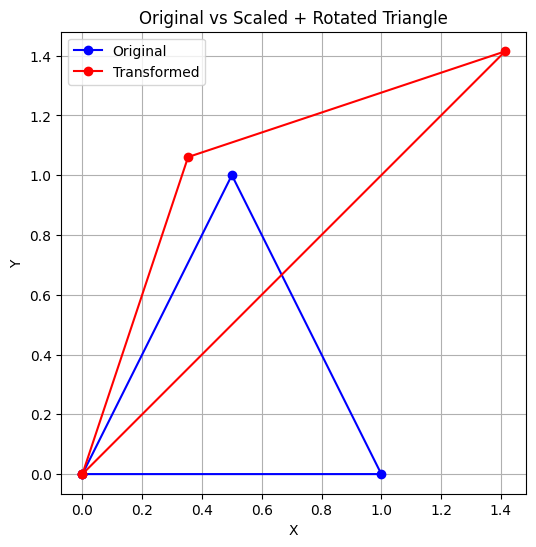

In [17]:
import numpy as np
import matplotlib.pyplot as plt

tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])   # 3 corners of a triangle

# 1. Scaling matrix (x*2, y*0.5)
S = np.array([[2, 0],
              [0, 0.5]])

scaled = S @ tri

# 2. Rotation matrix (45 degrees)
theta = np.radians(45)

R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

rotated = R @ scaled

# 3. Apply both and plot original vs transformed
plt.figure(figsize=(6, 6))

# Original triangle
plt.plot(np.append(tri[0], tri[0, 0]),
         np.append(tri[1], tri[1, 0]),
         'bo-', label='Original')

# Transformed triangle
plt.plot(np.append(rotated[0], rotated[0, 0]),
         np.append(rotated[1], rotated[1, 0]),
         'ro-', label='Transformed')

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Original vs Scaled + Rotated Triangle")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()


In [18]:
import numpy as np

C = np.array([[4., 1.],
              [2., 3.]])

# 1. eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(C)

# 2. print eigenvalues
print("Eigenvalues:")
print(eigenvalues)

print("Eigenvectors:")
print(eigenvectors)

# 3. verify A v = lambda v for the first eigenvector
v = eigenvectors[:, 0]
lam = eigenvalues[0]

print("A v:")
print(C @ v)

print("lambda v:")
print(lam * v)

print("A v == lambda v:", np.allclose(C @ v, lam * v))


Eigenvalues:
[5. 2.]
Eigenvectors:
[[ 0.707 -0.447]
 [ 0.707  0.894]]
A v:
[3.536 3.536]
lambda v:
[3.536 3.536]
A v == lambda v: True


In [19]:
import numpy as np

A2 = np.array([[3., 2.],
               [1., 4.]])
b2 = np.array([7., 9.])

cat = np.array([0.9, 0.8, 0.1])
dog = np.array([0.85, 0.7, 0.2])
car = np.array([0.1, 0.2, 0.95])

# 1. Solve A2 x = b2
x = np.linalg.solve(A2, b2)
print("Solution x:", x)

# 2. Rank of A2
rank = np.linalg.matrix_rank(A2)
print("Rank of A2:", rank)

# 3. cosine(cat, dog) and cosine(cat, car); which is more similar?
cos_cat_dog = np.dot(cat, dog) / (np.linalg.norm(cat) * np.linalg.norm(dog))
cos_cat_car = np.dot(cat, car) / (np.linalg.norm(cat) * np.linalg.norm(car))

print("Cosine(cat, dog):", cos_cat_dog)
print("Cosine(cat, car):", cos_cat_car)

if cos_cat_dog > cos_cat_car:
    print("Cat and dog are more similar.")
else:
    print("Cat and car are more similar.")


Solution x: [1. 2.]
Rank of A2: 2
Cosine(cat, dog): 0.9946195449838785
Cosine(cat, car): 0.29255678516966266
Cat and dog are more similar.
